In [ ]:
import pandas as pd

# 상대 경로 직접 사용 (notebook 위치 기준)
df = pd.read_csv('../../../../../data/ML/preprocessed_office_data.csv')
print(f"데이터 로드 완료: {len(df)} rows")
df.info()

데이터 로드 완료: 356 rows


# 거래 성사율

In [31]:
# 1. 숫자 변환 (예: "51건", "9건" → 51, 9)
def to_int(x):
    if isinstance(x, str):
        return int(x.replace("건", "").strip())
    return x

df["거래완료"] = df["거래완료_숫자"].apply(to_int)
df["등록매물"] = df["등록매물_숫자"].apply(to_int)

# 2. 전체 매물 (거래완료 + 등록매물)
df["전체매물"] = df["거래완료"] + df["등록매물"]

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

# 3. 거래성사율 계산 (0으로 나누기 방지)
df["거래성사율"] = df["거래완료"] / (df["전체매물"] + 1e-6)

print(df[["거래완료", "등록매물", "전체매물", "거래성사율"]].head())


    거래완료  등록매물   전체매물     거래성사율
0  161.0  10.0  171.0  0.941520
1   76.0   5.0   81.0  0.938272
2  403.0  12.0  415.0  0.971084
3  152.0  12.0  164.0  0.926829
4  380.0  14.0  394.0  0.964467


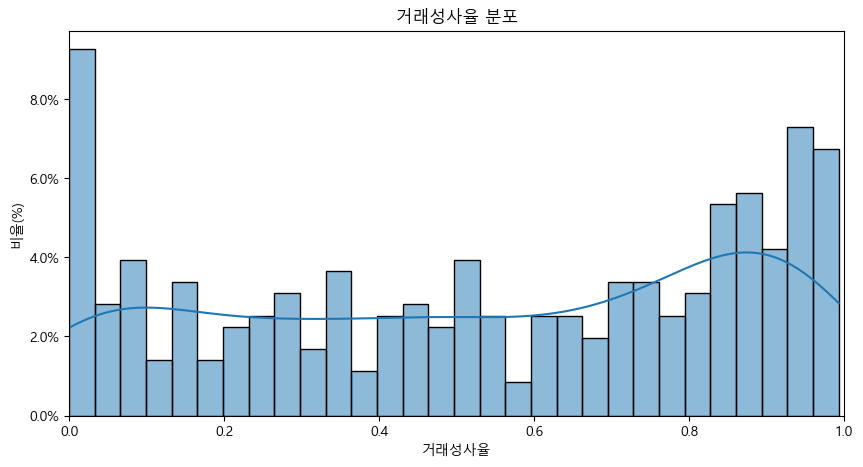

In [33]:
# 한글 폰트 설정 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(10,5))
sns.histplot(df["거래성사율"], bins=30, kde=True, stat="probability")

plt.xlim(0, 1)
plt.xlabel("거래성사율")
plt.ylabel("비율(%)")
plt.title("거래성사율 분포")
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.show()

# 지역별 Z-score
- 지역별 거래 성사율의 평균, 표준편차를 계산

In [20]:
# 지역별 평균과 표준편차 계산
region_mean = df.groupby("지역명")["거래성사율"].transform("mean")
region_std  = df.groupby("지역명")["거래성사율"].transform("std")

# Z-score 생성  
df["지역대비_Z"] = (df["거래성사율"] - region_mean) / (region_std + 1e-6)


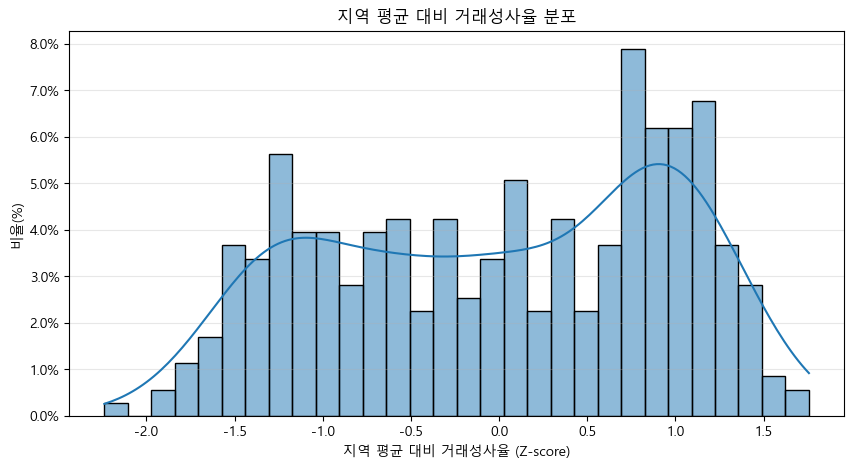

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

plt.figure(figsize=(10,5))

sns.histplot(df["지역대비_Z"], bins=30, kde=True, stat="probability")

plt.xlabel("지역 평균 대비 거래성사율 (Z-score)")
plt.ylabel("비율(%)")
plt.title("지역 평균 대비 거래성사율 분포")

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.grid(axis='y', alpha=0.3)

plt.show()


#  개인성사율이 지역 평균보다 얼마나 높은지
# -------------------------------------
#  그 지역 성사율이 원래 얼마나 들쭉날쭉한가

## 지역별 평균/표준편차 계산 → 개인별 Z-score 생성 → A/B/C 등급 생성 → 요약표 + 그래프 시각화

### 지역별 평균/표준편차 계산

In [75]:
import pandas as pd
import numpy as np

# -----------------------------
# 1) 지역별 평균 성사율 / 표준편차 계산
# -----------------------------
df["지역평균"] = df.groupby("지역명")["거래성사율"].transform("mean")
df["지역표준편차"] = df.groupby("지역명")["거래성사율"].transform("std")

# -----------------------------
# 2) 개인별 Z-score 생성
# -----------------------------
df["Zscore"] = (df["거래성사율"] - df["지역평균"]) / (df["지역표준편차"] + 1e-6)


In [77]:
# 분위수 경계 계산
q30 = df["Zscore"].quantile(0.30)
q70 = df["Zscore"].quantile(0.70)

print("분위수 기준값:")
print("  C 등급 최대:", q30)
print("  B 등급 최대:", q70)

# 등급화
def classify(z):
    if z <= q30:
        return "C"   # 하위
    elif z <= q70:
        return "B"   # 중간
    else:
        return "A"   # 상위

df["등급"] = df["Zscore"].apply(classify)


분위수 기준값:
  C 등급 최대: -0.6872787487741612
  B 등급 최대: 0.7582093571860821


In [78]:
summary = df.groupby("지역명").agg(
    지역평균=("거래성사율", "mean"),
    표준편차=("거래성사율", "std"),
    중개사수=("거래성사율", "count"),
    A등급=("등급", lambda x: (x=="A").sum()),
    B등급=("등급", lambda x: (x=="B").sum()),
    C등급=("등급", lambda x: (x=="C").sum()),
)

summary["A비율"] = summary["A등급"] / summary["중개사수"]
summary["B비율"] = summary["B등급"] / summary["중개사수"]
summary["C비율"] = summary["C등급"] / summary["중개사수"]

summary = summary.round(3)
summary


,지역평균,표준편차,중개사수,A등급,B등급,C등급,A비율,B비율,C비율
지역명,,,,,,,,,
강남구,0.426,0.340,50,16,16,18,0.320,0.320,0.360
강동구,0.407,0.260,6,1,4,1,0.167,0.667,0.167
강북구,0.732,0.243,6,3,2,1,0.500,0.333,0.167
강서구,0.549,0.308,30,8,14,8,0.267,0.467,0.267
관악구,0.500,0.326,68,19,30,19,0.279,0.441,0.279
광진구,0.616,0.322,24,6,11,7,0.250,0.458,0.292
구로구,0.562,0.305,7,2,3,2,0.286,0.429,0.286
금천구,0.489,0.389,19,7,4,8,0.368,0.211,0.421
노원구,0.944,NaN,1,1,0,0,1.000,0.000,0.000


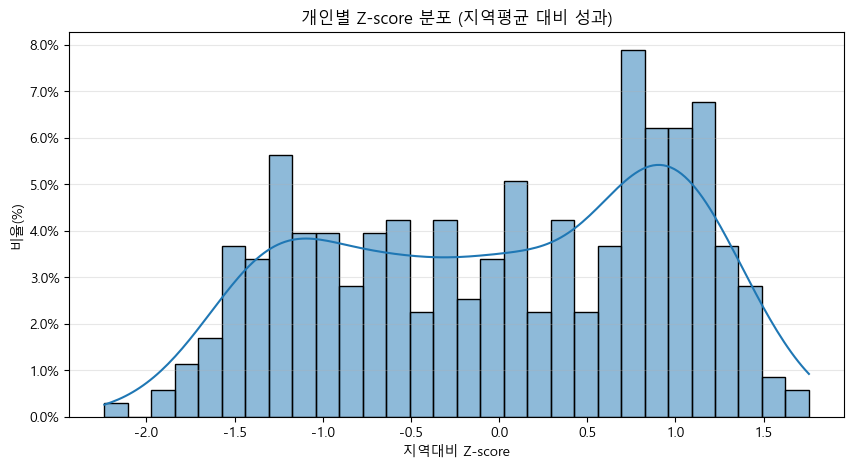

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

plt.figure(figsize=(10,5))
sns.histplot(df["Zscore"], bins=30, kde=True, stat="probability")

plt.xlabel("지역대비 Z-score")
plt.ylabel("비율(%)")
plt.title("개인별 Z-score 분포 (지역평균 대비 성과)")
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.grid(axis='y', alpha=0.3)
plt.show()


In [80]:
region_stats = df.groupby("지역명").agg(
    평균성사율=("거래성사율", "mean"),
    표준편차=("거래성사율", "std"),
    개수=("거래성사율", "count")
).round(3)

region_stats


,평균성사율,표준편차,개수
지역명,,,
강남구,0.426,0.340,50
강동구,0.407,0.260,6
강북구,0.732,0.243,6
강서구,0.549,0.308,30
관악구,0.500,0.326,68
광진구,0.616,0.322,24
구로구,0.562,0.305,7
금천구,0.489,0.389,19
노원구,0.944,NaN,1


### 개인별 Z-score 생성

In [82]:
# 1) 개인별 지역평균 / 지역표준편차 다시 병합
df["지역평균"] = df.groupby("지역명")["거래성사율"].transform("mean")
df["지역표준편차"] = df.groupby("지역명")["거래성사율"].transform("std")

# 2) 개인별 Z-score 계산
df["Zscore"] = (df["거래성사율"] - df["지역평균"]) / (df["지역표준편차"] + 1e-6)


> A/B/C 기준(분위수) 자동 계산

In [83]:
q30 = df["Zscore"].quantile(0.30)
q70 = df["Zscore"].quantile(0.70)

print("C 등급 상한:", q30)
print("B 등급 상한:", q70)


C 등급 상한: -0.6872787487741612
B 등급 상한: 0.7582093571860821


> 개인별 A/B/C 등급 부여

In [84]:
def classify(z):
    if z <= q30:
        return "C"   # 하위 30%
    elif z <= q70:
        return "B"   # 중간 40%
    else:
        return "A"   # 상위 30%

df["등급"] = df["Zscore"].apply(classify)


> 등급분포 확인하기 

In [85]:
df["등급"].value_counts(normalize=True)

등급
B    0.396067
A    0.303371
C    0.300562
Name: proportion, dtype: float64

> 지역별 A/B/C 분포 확인

In [ ]:
grade_summary = df.groupby("지역명")["등급"].value_counts().unstack().fillna(0)
grade_summary

등급,A,B,C
지역명,,,
강남구,16.0,16.0,18.0
강동구,1.0,4.0,1.0
강북구,3.0,2.0,1.0
강서구,8.0,14.0,8.0
관악구,19.0,30.0,19.0
광진구,6.0,11.0,7.0
구로구,2.0,3.0,2.0
금천구,7.0,4.0,8.0
노원구,1.0,0.0,0.0


# 구별 매물 수 / 서울시 전체 매물수

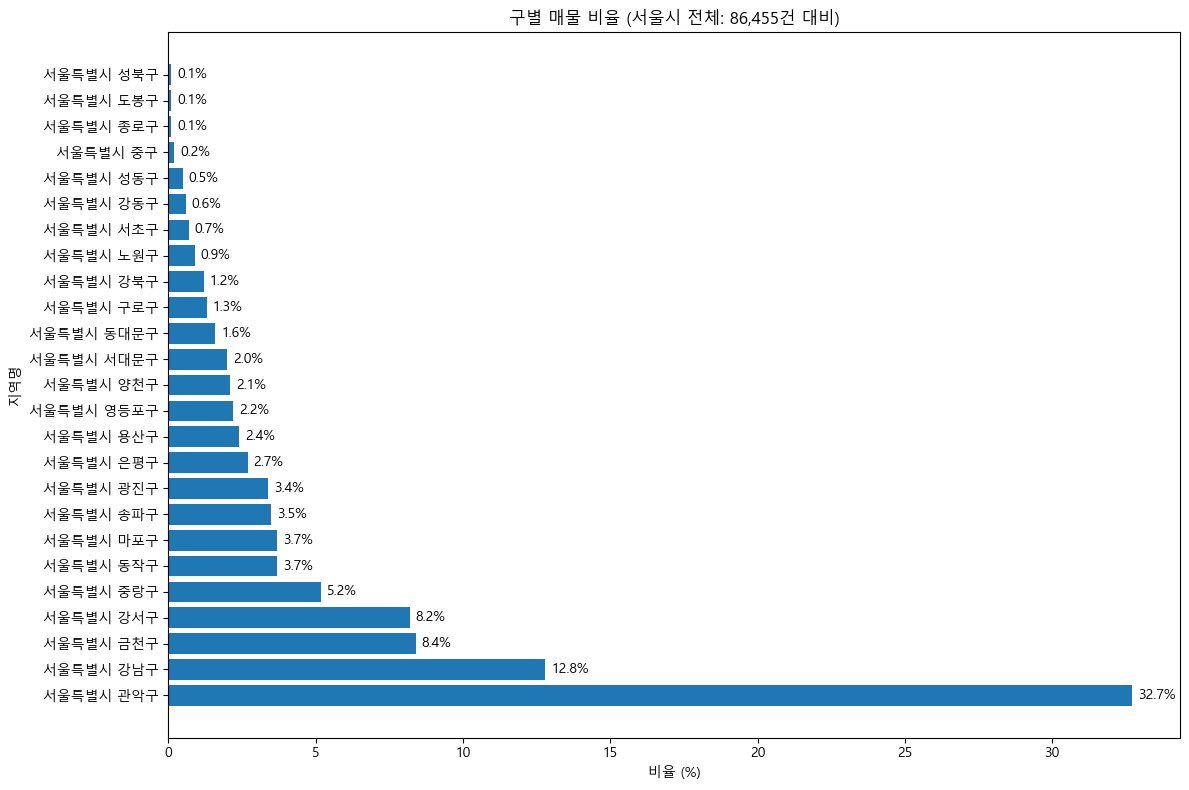

구별 매물 비율:
서울특별시 관악구: 28,278건 / 86,455건 = 32.7%
서울특별시 강남구: 11,042건 / 86,455건 = 12.8%
서울특별시 금천구: 7,223건 / 86,455건 = 8.4%
서울특별시 강서구: 7,108건 / 86,455건 = 8.2%
서울특별시 중랑구: 4,461건 / 86,455건 = 5.2%
서울특별시 동작구: 3,195건 / 86,455건 = 3.7%
서울특별시 마포구: 3,183건 / 86,455건 = 3.7%
서울특별시 송파구: 3,045건 / 86,455건 = 3.5%
서울특별시 광진구: 2,928건 / 86,455건 = 3.4%
서울특별시 은평구: 2,343건 / 86,455건 = 2.7%
서울특별시 용산구: 2,043건 / 86,455건 = 2.4%
서울특별시 영등포구: 1,931건 / 86,455건 = 2.2%
서울특별시 양천구: 1,778건 / 86,455건 = 2.1%
서울특별시 서대문구: 1,705건 / 86,455건 = 2.0%
서울특별시 동대문구: 1,376건 / 86,455건 = 1.6%
서울특별시 구로구: 1,152건 / 86,455건 = 1.3%
서울특별시 강북구: 1,000건 / 86,455건 = 1.2%
서울특별시 노원구: 735건 / 86,455건 = 0.9%
서울특별시 서초구: 602건 / 86,455건 = 0.7%
서울특별시 강동구: 512건 / 86,455건 = 0.6%
서울특별시 성동구: 461건 / 86,455건 = 0.5%
서울특별시 중구: 140건 / 86,455건 = 0.2%
서울특별시 종로구: 86건 / 86,455건 = 0.1%
서울특별시 도봉구: 70건 / 86,455건 = 0.1%
서울특별시 성북구: 58건 / 86,455건 = 0.1%


In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# 구별 매물 수 계산
district_total = df.groupby('지역명')['전체매물'].sum().sort_values(ascending=False)

# 서울시 전체 매물 수
seoul_total = df['전체매물'].sum()

# 비율 계산 (구별 매물 수 / 서울시 전체 매물 수 * 100)
district_ratio = (district_total / seoul_total * 100).round(1)

# 그래프 그리기
plt.figure(figsize=(12, 8))
plt.barh(district_ratio.index, district_ratio.values)
plt.xlabel('비율 (%)')
plt.ylabel('지역명')
plt.title(f'구별 매물 비율 (서울시 전체: {seoul_total:,}건 대비)')

# 값 표시
for i, v in enumerate(district_ratio.values):
    plt.text(v + 0.2, i, f'{v}%', va='center')

plt.tight_layout()
plt.show()

print("구별 매물 비율:")
for region, ratio in district_ratio.items():
    count = district_total[region]
    print(f"{region}: {count:,}건 / {seoul_total:,}건 = {ratio}%")


# 구별 전체 매물 대비 거래된 매물 비율

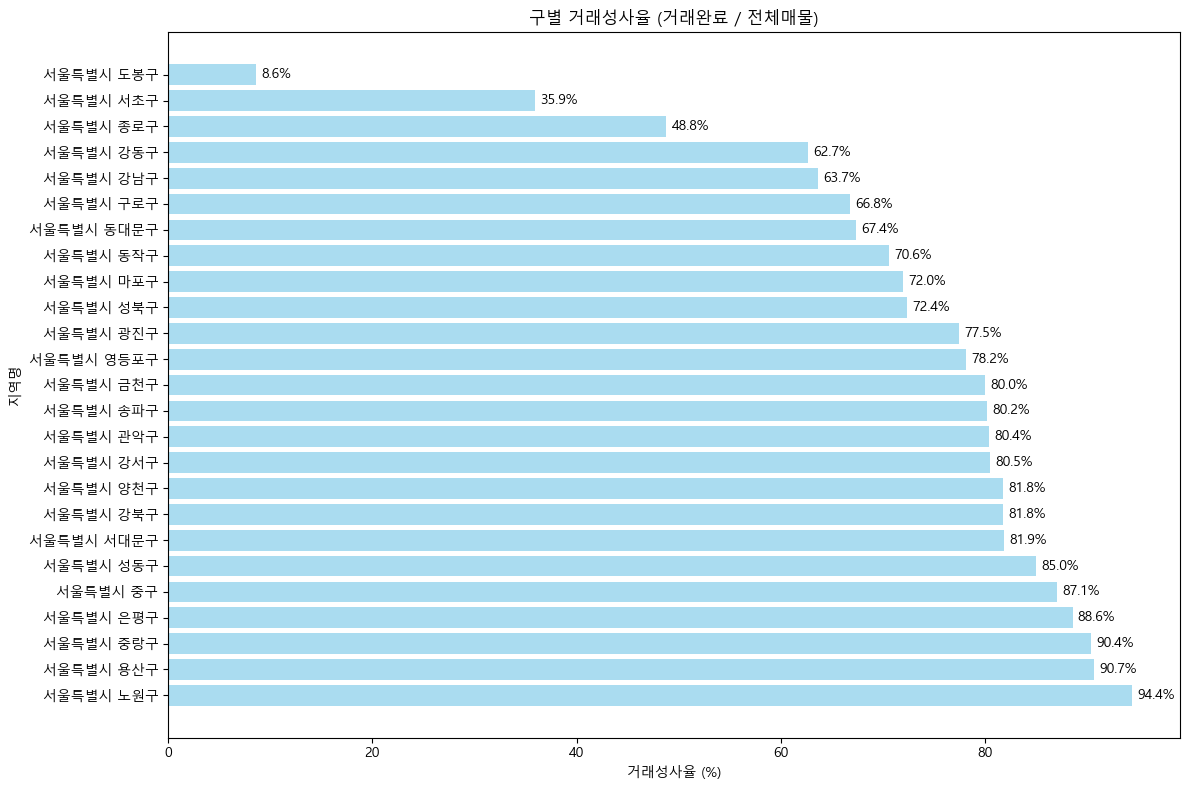

구별 거래성사율:
서울특별시 노원구: 694건 / 735건 = 94.4%
서울특별시 용산구: 1,852건 / 2,043건 = 90.7%
서울특별시 중랑구: 4,031건 / 4,461건 = 90.4%
서울특별시 은평구: 2,076건 / 2,343건 = 88.6%
서울특별시 중구: 122건 / 140건 = 87.1%
서울특별시 성동구: 392건 / 461건 = 85.0%
서울특별시 서대문구: 1,397건 / 1,705건 = 81.9%
서울특별시 강북구: 818건 / 1,000건 = 81.8%
서울특별시 양천구: 1,455건 / 1,778건 = 81.8%
서울특별시 강서구: 5,723건 / 7,108건 = 80.5%
서울특별시 관악구: 22,740건 / 28,278건 = 80.4%
서울특별시 송파구: 2,441건 / 3,045건 = 80.2%
서울특별시 금천구: 5,776건 / 7,223건 = 80.0%
서울특별시 영등포구: 1,511건 / 1,931건 = 78.2%
서울특별시 광진구: 2,268건 / 2,928건 = 77.5%
서울특별시 성북구: 42건 / 58건 = 72.4%
서울특별시 마포구: 2,291건 / 3,183건 = 72.0%
서울특별시 동작구: 2,255건 / 3,195건 = 70.6%
서울특별시 동대문구: 928건 / 1,376건 = 67.4%
서울특별시 구로구: 770건 / 1,152건 = 66.8%
서울특별시 강남구: 7,033건 / 11,042건 = 63.7%
서울특별시 강동구: 321건 / 512건 = 62.7%
서울특별시 종로구: 42건 / 86건 = 48.8%
서울특별시 서초구: 216건 / 602건 = 35.9%
서울특별시 도봉구: 6건 / 70건 = 8.6%


In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# 구별 거래완료 건수와 전체매물 수 계산
district_stats = df.groupby('지역명').agg({
    '거래완료': 'sum',
    '전체매물': 'sum'
}).reset_index()

# 거래성사율 계산
district_stats['거래성사율'] = (district_stats['거래완료'] / district_stats['전체매물'] * 100).round(1)

# 거래성사율 기준으로 내림차순 정렬
district_stats = district_stats.sort_values('거래성사율', ascending=False)

# 그래프 그리기
plt.figure(figsize=(12, 8))
plt.barh(district_stats['지역명'], district_stats['거래성사율'], color='skyblue', alpha=0.7)
plt.xlabel('거래성사율 (%)')
plt.ylabel('지역명')
plt.title('구별 거래성사율 (거래완료 / 전체매물)')

# 값 표시
for i, v in enumerate(district_stats['거래성사율']):
    plt.text(v + 0.5, i, f'{v}%', va='center')

plt.tight_layout()
plt.show()

# 통계 출력
print("구별 거래성사율:")
for _, row in district_stats.iterrows():
    print(f"{row['지역명']}: {row['거래완료']:,}건 / {row['전체매물']:,}건 = {row['거래성사율']}%")


# 구별 매물이 500건 이상만 추출하기

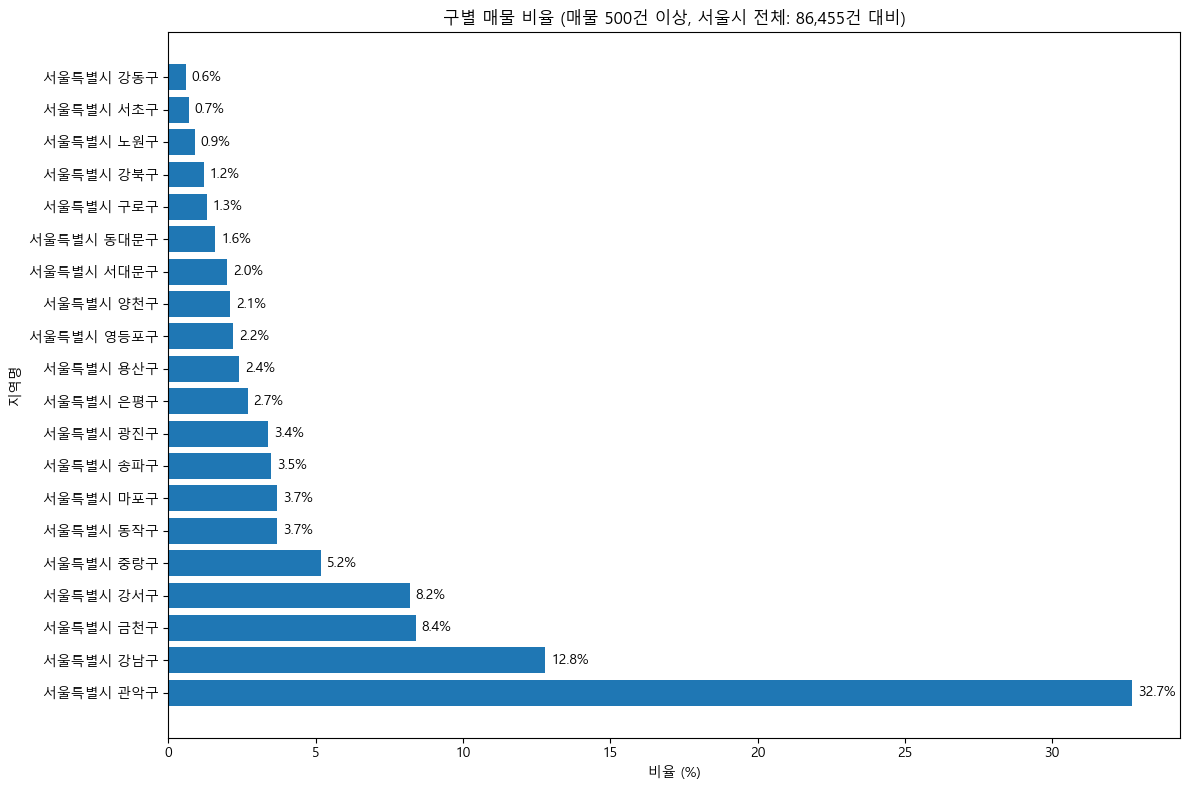

구별 매물 비율 (매물 500건 이상):
서울특별시 관악구: 28,278건 / 86,455건 = 32.7%
서울특별시 강남구: 11,042건 / 86,455건 = 12.8%
서울특별시 금천구: 7,223건 / 86,455건 = 8.4%
서울특별시 강서구: 7,108건 / 86,455건 = 8.2%
서울특별시 중랑구: 4,461건 / 86,455건 = 5.2%
서울특별시 동작구: 3,195건 / 86,455건 = 3.7%
서울특별시 마포구: 3,183건 / 86,455건 = 3.7%
서울특별시 송파구: 3,045건 / 86,455건 = 3.5%
서울특별시 광진구: 2,928건 / 86,455건 = 3.4%
서울특별시 은평구: 2,343건 / 86,455건 = 2.7%
서울특별시 용산구: 2,043건 / 86,455건 = 2.4%
서울특별시 영등포구: 1,931건 / 86,455건 = 2.2%
서울특별시 양천구: 1,778건 / 86,455건 = 2.1%
서울특별시 서대문구: 1,705건 / 86,455건 = 2.0%
서울특별시 동대문구: 1,376건 / 86,455건 = 1.6%
서울특별시 구로구: 1,152건 / 86,455건 = 1.3%
서울특별시 강북구: 1,000건 / 86,455건 = 1.2%
서울특별시 노원구: 735건 / 86,455건 = 0.9%
서울특별시 서초구: 602건 / 86,455건 = 0.7%
서울특별시 강동구: 512건 / 86,455건 = 0.6%

필터링된 구 개수: 20개
전체 구 개수: 25개


In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# 구별 매물 수 계산
district_total = df.groupby('지역명')['전체매물'].sum().sort_values(ascending=False)

# 매물 500건 이상인 구만 필터링
filtered_district_total = district_total[district_total >= 500]

# 서울시 전체 매물 수
seoul_total = df['전체매물'].sum()

# 비율 계산 (구별 매물 수 / 서울시 전체 매물 수 * 100)
filtered_district_ratio = (filtered_district_total / seoul_total * 100).round(1)

# 그래프 그리기
plt.figure(figsize=(12, 8))
plt.barh(filtered_district_ratio.index, filtered_district_ratio.values)
plt.xlabel('비율 (%)')
plt.ylabel('지역명')
plt.title(f'구별 매물 비율 (매물 500건 이상, 서울시 전체: {seoul_total:,}건 대비)')

# 값 표시
for i, v in enumerate(filtered_district_ratio.values):
    plt.text(v + 0.2, i, f'{v}%', va='center')

plt.tight_layout()
plt.show()

print("구별 매물 비율 (매물 500건 이상):")
for region, ratio in filtered_district_ratio.items():
    count = filtered_district_total[region]
    print(f"{region}: {count:,}건 / {seoul_total:,}건 = {ratio}%")

print(f"\n필터링된 구 개수: {len(filtered_district_ratio)}개")
print(f"전체 구 개수: {len(district_total)}개")


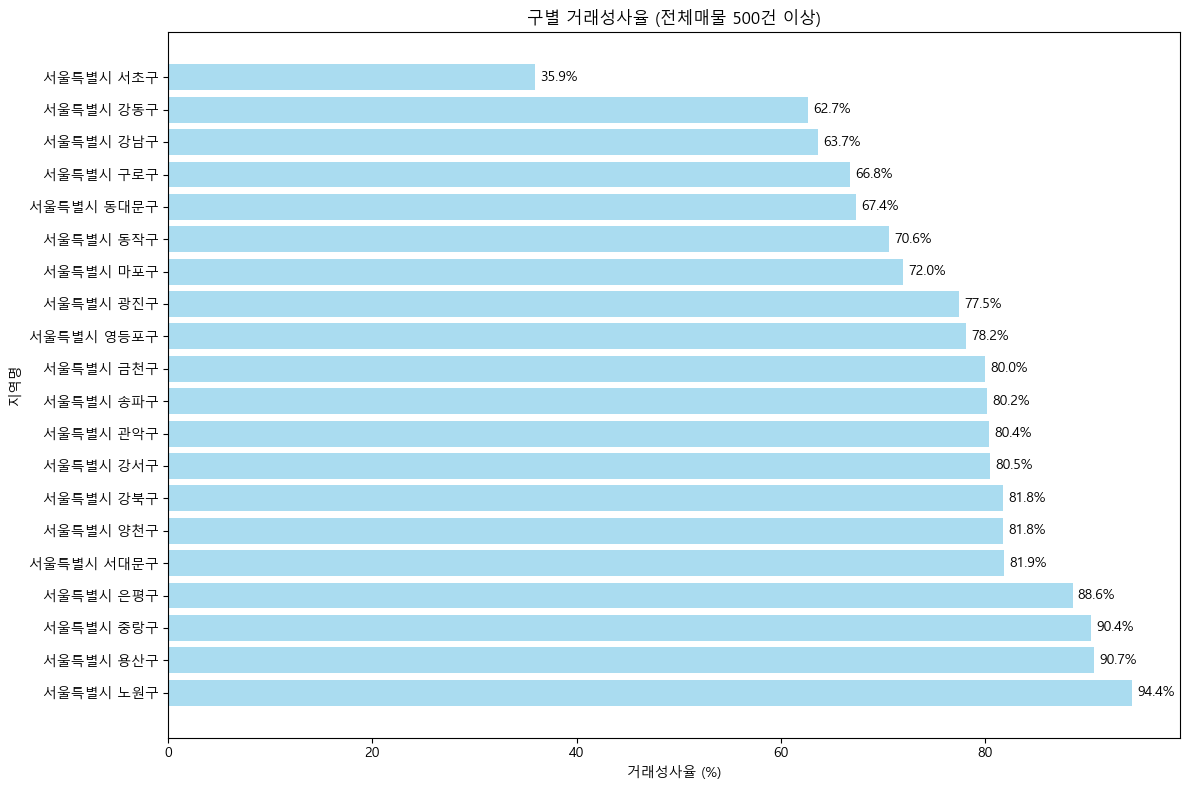

구별 거래성사율 (전체매물 500건 이상):
서울특별시 노원구: 694건 / 735건 = 94.4%
서울특별시 용산구: 1,852건 / 2,043건 = 90.7%
서울특별시 중랑구: 4,031건 / 4,461건 = 90.4%
서울특별시 은평구: 2,076건 / 2,343건 = 88.6%
서울특별시 서대문구: 1,397건 / 1,705건 = 81.9%
서울특별시 양천구: 1,455건 / 1,778건 = 81.8%
서울특별시 강북구: 818건 / 1,000건 = 81.8%
서울특별시 강서구: 5,723건 / 7,108건 = 80.5%
서울특별시 관악구: 22,740건 / 28,278건 = 80.4%
서울특별시 송파구: 2,441건 / 3,045건 = 80.2%
서울특별시 금천구: 5,776건 / 7,223건 = 80.0%
서울특별시 영등포구: 1,511건 / 1,931건 = 78.2%
서울특별시 광진구: 2,268건 / 2,928건 = 77.5%
서울특별시 마포구: 2,291건 / 3,183건 = 72.0%
서울특별시 동작구: 2,255건 / 3,195건 = 70.6%
서울특별시 동대문구: 928건 / 1,376건 = 67.4%
서울특별시 구로구: 770건 / 1,152건 = 66.8%
서울특별시 강남구: 7,033건 / 11,042건 = 63.7%
서울특별시 강동구: 321건 / 512건 = 62.7%
서울특별시 서초구: 216건 / 602건 = 35.9%

필터링된 구 개수: 20개
전체 구 개수: 25개


In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# 구별 거래완료 건수와 전체매물 수 계산
district_stats = df.groupby('지역명').agg({
    '거래완료': 'sum',
    '전체매물': 'sum'
}).reset_index()

# 거래성사율 계산
district_stats['거래성사율'] = (district_stats['거래완료'] / district_stats['전체매물'] * 100).round(1)

# 전체매물 500건 이상인 구만 필터링
filtered_district_stats = district_stats[district_stats['전체매물'] >= 500]

# 거래성사율 기준으로 내림차순 정렬
filtered_district_stats = filtered_district_stats.sort_values('거래성사율', ascending=False)

# 그래프 그리기
plt.figure(figsize=(12, 8))
plt.barh(filtered_district_stats['지역명'], filtered_district_stats['거래성사율'], color='skyblue', alpha=0.7)
plt.xlabel('거래성사율 (%)')
plt.ylabel('지역명')
plt.title('구별 거래성사율 (전체매물 500건 이상)')

# 값 표시
for i, v in enumerate(filtered_district_stats['거래성사율']):
    plt.text(v + 0.5, i, f'{v}%', va='center')

plt.tight_layout()
plt.show()

# 통계 출력
print("구별 거래성사율 (전체매물 500건 이상):")
for _, row in filtered_district_stats.iterrows():
    print(f"{row['지역명']}: {row['거래완료']:,}건 / {row['전체매물']:,}건 = {row['거래성사율']}%")

print(f"\n필터링된 구 개수: {len(filtered_district_stats)}개")
print(f"전체 구 개수: {len(district_stats)}개")


# 서울 전체 중개업소 대비 구별 중개소 비율

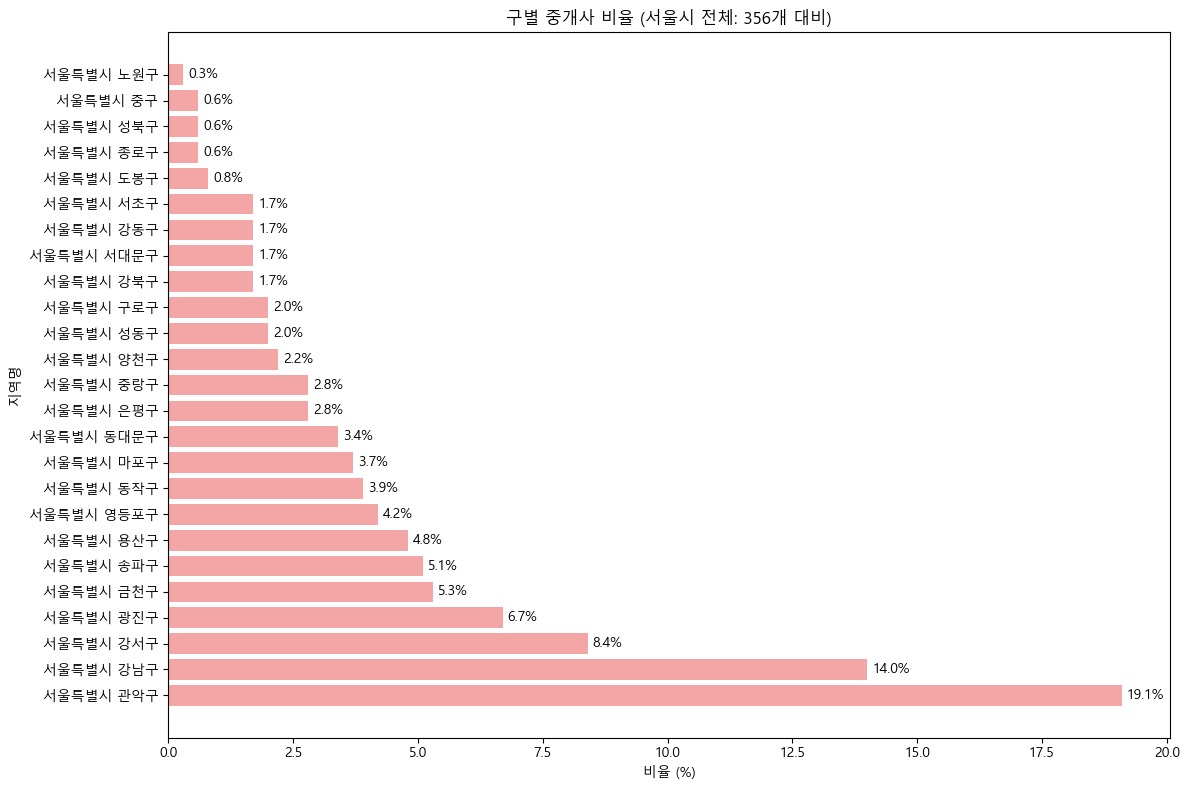

구별 중개사 비율 (서울시 전체 대비):
서울특별시 관악구: 68개 / 356개 = 19.1%
서울특별시 강남구: 50개 / 356개 = 14.0%
서울특별시 강서구: 30개 / 356개 = 8.4%
서울특별시 광진구: 24개 / 356개 = 6.7%
서울특별시 금천구: 19개 / 356개 = 5.3%
서울특별시 송파구: 18개 / 356개 = 5.1%
서울특별시 용산구: 17개 / 356개 = 4.8%
서울특별시 영등포구: 15개 / 356개 = 4.2%
서울특별시 동작구: 14개 / 356개 = 3.9%
서울특별시 마포구: 13개 / 356개 = 3.7%
서울특별시 동대문구: 12개 / 356개 = 3.4%
서울특별시 은평구: 10개 / 356개 = 2.8%
서울특별시 중랑구: 10개 / 356개 = 2.8%
서울특별시 양천구: 8개 / 356개 = 2.2%
서울특별시 성동구: 7개 / 356개 = 2.0%
서울특별시 구로구: 7개 / 356개 = 2.0%
서울특별시 강북구: 6개 / 356개 = 1.7%
서울특별시 서대문구: 6개 / 356개 = 1.7%
서울특별시 강동구: 6개 / 356개 = 1.7%
서울특별시 서초구: 6개 / 356개 = 1.7%
서울특별시 도봉구: 3개 / 356개 = 0.8%
서울특별시 종로구: 2개 / 356개 = 0.6%
서울특별시 성북구: 2개 / 356개 = 0.6%
서울특별시 중구: 2개 / 356개 = 0.6%
서울특별시 노원구: 1개 / 356개 = 0.3%

서울시 전체: 356개 (100.0%)


In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# 구별 중개사 수 계산
district_broker_count = df.groupby('지역명').size().sort_values(ascending=False)

# 서울시 전체 중개사 수
seoul_total_brokers = district_broker_count.sum()

# 비율 계산 (구별 중개사 수 / 서울시 전체 중개사 수 * 100)
district_broker_ratio = (district_broker_count / seoul_total_brokers * 100).round(1)

# 그래프 그리기
plt.figure(figsize=(12, 8))
plt.barh(district_broker_ratio.index, district_broker_ratio.values, color='lightcoral', alpha=0.7)
plt.xlabel('비율 (%)')
plt.ylabel('지역명')
plt.title(f'구별 중개사 비율 (서울시 전체: {seoul_total_brokers}개 대비)')

# 값 표시
for i, v in enumerate(district_broker_ratio.values):
    plt.text(v + 0.1, i, f'{v}%', va='center')

plt.tight_layout()
plt.show()

# 통계 출력
print("구별 중개사 비율 (서울시 전체 대비):")
for region, ratio in district_broker_ratio.items():
    count = district_broker_count[region]
    print(f"{region}: {count}개 / {seoul_total_brokers}개 = {ratio}%")

print(f"\n서울시 전체: {seoul_total_brokers}개 (100.0%)")


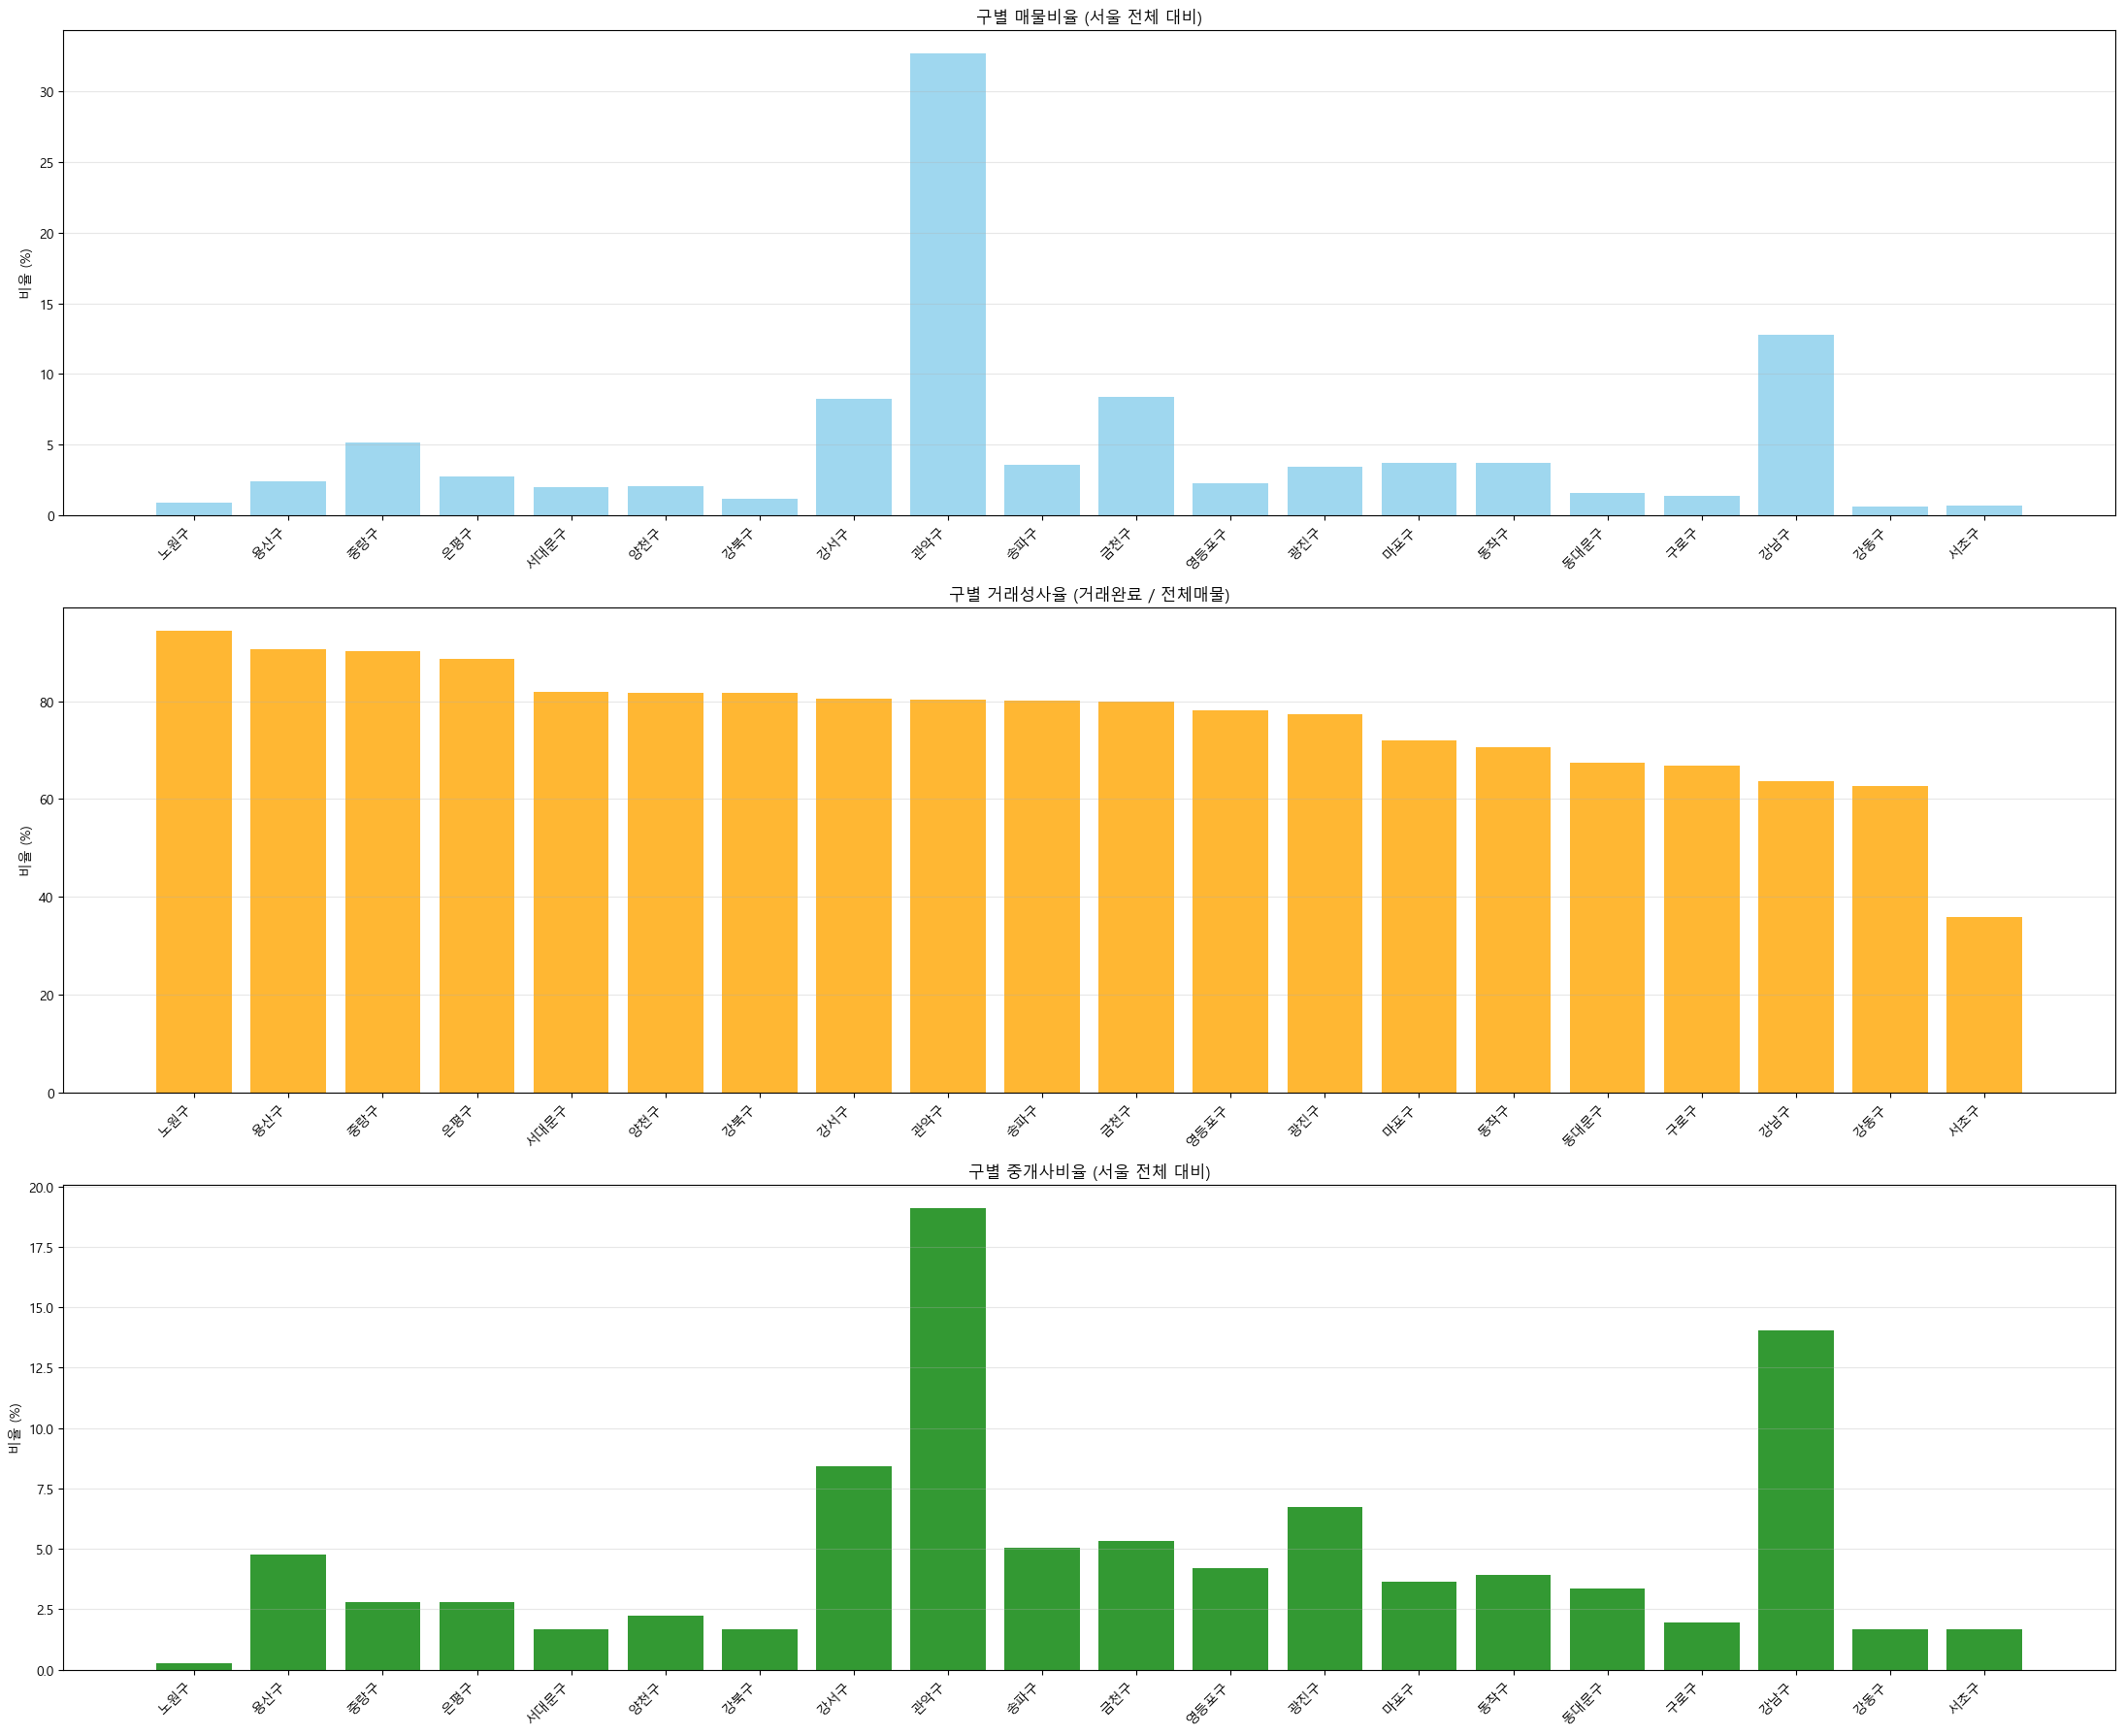

구별 지표 비교 (서울시 전체 대비 비율):
     지역명  매물비율(%)  거래성사율(%)  중개사비율(%)   전체매물
8    노원구      0.9      94.4       0.3    735
20   용산구      2.4      90.7       4.8   2043
24   중랑구      5.2      90.4       2.8   4461
21   은평구      2.7      88.6       2.8   2343
13  서대문구      2.0      81.9       1.7   1705
18   양천구      2.1      81.8       2.2   1778
2    강북구      1.2      81.8       1.7   1000
3    강서구      8.2      80.5       8.4   7108
4    관악구     32.7      80.4      19.1  28278
17   송파구      3.5      80.2       5.1   3045
7    금천구      8.4      80.0       5.3   7223
19  영등포구      2.2      78.2       4.2   1931
5    광진구      3.4      77.5       6.7   2928
12   마포구      3.7      72.0       3.7   3183
11   동작구      3.7      70.6       3.9   3195
10  동대문구      1.6      67.4       3.4   1376
6    구로구      1.3      66.8       2.0   1152
0    강남구     12.8      63.7      14.0  11042
1    강동구      0.6      62.7       1.7    512
14   서초구      0.7      35.9       1.7    602

서울시 전체 매물: 86,455건
서울시 전체 중개사

In [72]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ================================
# 0) 지역명에서 '서울특별시', '서울시' 제거
# ================================
df['지역명'] = df['지역명'].apply(lambda x: x.split()[-1])


# ================================
# 1) 구별 서울 전체 매물 대비 비율
# ================================
district_total = df.groupby('지역명')['전체매물'].sum()
seoul_total = df['전체매물'].sum()
district_ratio = (district_total / seoul_total * 100)

# ================================
# 2) 구별 거래성사율 (거래완료 / 전체매물)
# ================================
district_stats = df.groupby('지역명').agg({
    '거래완료': 'sum',
    '전체매물': 'sum'
})
district_success_rate = (district_stats['거래완료'] / district_stats['전체매물'] * 100)

# ================================
# 3) 구별 중개사 수 비율 (서울 전체 대비)
# ================================
district_agent_count = df.groupby('지역명').size()
seoul_total_agents = district_agent_count.sum()
district_agent_ratio = (district_agent_count / seoul_total_agents * 100)

# ================================
# 4) 하나의 DF로 합치기 + 매물 500건 이상 필터링
# ================================
combined = pd.DataFrame({
    '지역명': district_ratio.index,
    '매물비율(%)': district_ratio.values,
    '거래성사율(%)': district_success_rate.values,
    '중개사비율(%)': district_agent_ratio.values,
    '전체매물': district_stats['전체매물'].values
})

# 매물 500건 이상인 지역만 필터링
combined = combined[combined['전체매물'] >= 500]

# 보기 좋게 거래성사율 기준 정렬
combined = combined.sort_values('거래성사율(%)', ascending=False)

regions = combined['지역명']
x = np.arange(len(regions))

# ================================
# 5) Subplot 3개 그리기 (각각 x축 지역명 표시)
# ================================
fig, axes = plt.subplots(3, 1, figsize=(22, 18))  # sharex 제거

# --- 1. 매물비율 ---
axes[0].bar(x, combined['매물비율(%)'], color='skyblue', alpha=0.8)
axes[0].set_title("구별 매물비율 (서울 전체 대비)")
axes[0].set_ylabel("비율 (%)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(regions, rotation=45, ha='right')
axes[0].grid(axis='y', alpha=0.3)

# --- 2. 거래성사율 ---
axes[1].bar(x, combined['거래성사율(%)'], color='orange', alpha=0.8)
axes[1].set_title("구별 거래성사율 (거래완료 / 전체매물)")
axes[1].set_ylabel("비율 (%)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(regions, rotation=45, ha='right')
axes[1].grid(axis='y', alpha=0.3)

# --- 3. 중개사비율 ---
axes[2].bar(x, combined['중개사비율(%)'], color='green', alpha=0.8)
axes[2].set_title("구별 중개사비율 (서울 전체 대비)")
axes[2].set_ylabel("비율 (%)")
axes[2].set_xticks(x)
axes[2].set_xticklabels(regions, rotation=45, ha='right')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ---- 통계 출력 ----
print("구별 지표 비교 (서울시 전체 대비 비율):")
print(combined.round(1))
print(f"\n서울시 전체 매물: {seoul_total:,}건")
print(f"서울시 전체 중개사: {seoul_total_agents}개")
